In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
#we'll use these helper functions to generate a polynomial basis on the feature data matrices X

def poly_basis_single_sample(x, k):
    #this function will help us quickly generate a polynomial basis
    #k is the largest polynomial degree the basis runs to
    out = []
    for i in range(k+1):
        #notice that first value of i will be 0, so the bias term is included
        out.append(np.power(x, i))
    return(np.asarray(out))

#this one is not required for this assignment but can be used; we will use in the next assignment
def poly_basis_multi_sample(X, k):
    out = []
    for sample_row in range(X.shape[0]):
        sample = X[sample_row]
        #poly basis returns an m feature x k power matrix, we need to vectorize it by using .flatten()
        poly = np.asarray(poly_basis_single_sample(sample, k)).flatten() 
        out.append(poly)
    return(np.asarray(out))

In [5]:
#import the training data
data = np.loadtxt("homework_4_data_ex_train.txt")

#in this example there are 5 feature dimensions over 24 hours
X_train_raw = data[:,0:4]

#in order to use 2 hours at a time, we need to pair two hour rows together, one hour at a time, passing each
#hour sample through the polynomial basis function with a chosen degree:
poly_degree = 3
X_train = []
for i in range(24 - 2):  #24 hours minus the order
    #get the individual sample for each time step you need, pass it through the polynomial basis function, vectorize
    t_0 = poly_basis_single_sample(X_train_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_train_raw[i+1,:], poly_degree).flatten()
    X_train.append(np.concatenate((t_0, t_1)))
    
X_train = np.asarray(X_train)

#the last column is the output p_{t+1} we need to learn
#in order to save the data file, the Y column is 0-padded in the first two values, so we start from the third element
Y_train = data[:,5][2:]

In [4]:
#test data
data_test = np.loadtxt("homework_4_data_ex_test.txt")

X_test_raw = data_test[:,0:4]

poly_degree = 3
X_test = []
for i in range(24 - 2): 
    t_0 = poly_basis_single_sample(X_test_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_test_raw[i+1,:], poly_degree).flatten()
    X_test.append(np.concatenate((t_0, t_1)))
    
X_test = np.asarray(X_test)

Y_test = data_test[:,5][2:]

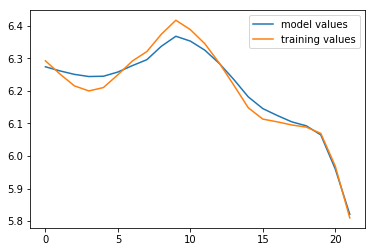

MAE:  0.021487734049601744


In [10]:
lasso_regressor = linear_model.Lasso(alpha=0.001, fit_intercept=False, tol=0.01, max_iter=10000)

#this fits the outputs Y to the polynomial basis of inputs in the range -2 to 2
lasso_regressor.fit(X_train, Y_train)

#these are the weights the model learns
w = lasso_regressor.coef_

plt.plot(X_train.dot(w), label="model values")   #our model
plt.plot(Y_train, label="training values")   #our training data
plt.legend()
plt.show()

mae = np.mean(np.abs(X_train.dot(w) - Y_train))
print("MAE: ", mae)

### Problem 1

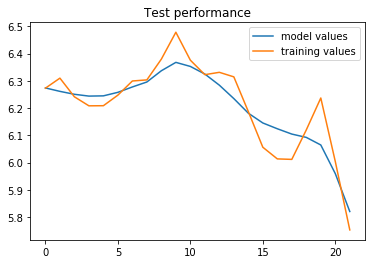

MAE:  0.049340974570973396


In [11]:
plt.title("Test performance")
plt.plot(X_test.dot(w), label="model values")   #our model
plt.plot(Y_test, label="training values")   #our training data
plt.legend()
plt.show()

print("MAE: ", np.mean(np.abs(X_test.dot(w) - Y_test)))

### Problem 2

In [18]:
poly_degree = 9

X_train_overfit = []
for i in range(24 - 2): 
    t_0 = poly_basis_single_sample(X_train_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_train_raw[i+1,:], poly_degree).flatten()
    X_train_overfit.append(np.concatenate((t_0, t_1)))
    
X_train_overfit = np.asarray(X_train_overfit)

X_test_overfit = []
for i in range(24 - 2): 
    t_0 = poly_basis_single_sample(X_test_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_test_raw[i+1,:], poly_degree).flatten()
    X_test_overfit.append(np.concatenate((t_0, t_1)))
    
X_test_overfit = np.asarray(X_test_overfit)

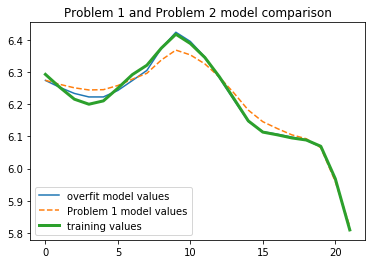

MAE:  0.021487734049601744
Overfit MAE:  0.006658763839297946


In [16]:
lasso_regressor_overfit = linear_model.Lasso(alpha=0.000001, fit_intercept=False, tol=0.01, max_iter=10000)

#this fits the outputs Y to the polynomial basis of inputs in the range -2 to 2
lasso_regressor_overfit.fit(X_train_overfit, Y_train)

#these are the weights the model learns
w_overfit = lasso_regressor_overfit.coef_

plt.title("Problem 1 and Problem 2 model comparison")
plt.plot(X_train_overfit.dot(w_overfit), label="overfit model values")
plt.plot(X_train.dot(w), "--", label="Problem 1 model values")
plt.plot(Y_train, lw=3, label="training values")   #our training data
plt.legend()
plt.show()

mae = np.mean(np.abs(X_train.dot(w) - Y_train))
print("MAE: ", mae)

mae_overfit = np.mean(np.abs(X_train_overfit.dot(w_overfit) - Y_train))
print("Overfit MAE: ", mae_overfit)

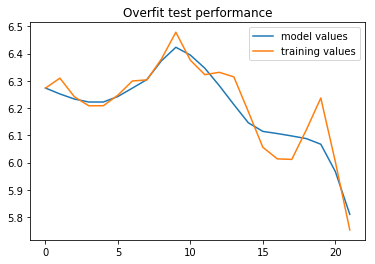

MAE:  0.04338365001122306


In [21]:
plt.title("Overfit test performance")
plt.plot(X_test_overfit.dot(w_overfit), label="model values")   #our model
plt.plot(Y_test, label="training values")   #our training data
plt.legend()
plt.show()

print("MAE: ", np.mean(np.abs(X_test_overfit.dot(w_overfit) - Y_test)))

In [25]:
print(w)
print("\n")
print(w_overfit)

[ 6.20750463e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.26223426e-02  6.72781223e-03 -7.73115502e-02 -7.09584253e-02
  7.61132739e-02  6.49494883e-02 -0.00000000e+00 -2.20919308e-01
  1.50538258e-01  6.26960339e-02 -0.00000000e+00 -2.03238811e-01
  4.16515132e-02  8.83131951e-18  7.88510671e-19  7.88510671e-19
  2.85652898e-02  0.00000000e+00 -8.12270097e-03 -3.91545261e-02
  6.78635695e-02  1.57514194e-02 -0.00000000e+00 -1.02225110e-01
  1.08635571e-01  2.33155481e-02 -0.00000000e+00 -9.33652392e-02]


[ 6.22043261e+00  8.52282919e-15  0.00000000e+00  0.00000000e+00
 -8.41060388e-03  3.22083645e-02 -2.16160378e-01 -4.57389680e-02
  1.00245376e-01  9.64665240e-02 -1.09110287e+00 -7.07059805e-02
  1.77820711e-01  1.20174954e-01 -2.74804076e+00 -6.08174667e-02
  1.72627689e-01  7.18429788e-02 -3.80107990e+00 -4.31252175e-02
  1.02506180e-01  1.95884016e-03  0.00000000e+00 -5.54679518e-02
  1.33942910e-02 -4.04767752e-02  0.00000000e+00  1.65453496e-02
 -5.84456294e-02 -4.67

### Problem 3

In [27]:
poly_degree = 3

X_train_overfit = []
for i in range(24 - 7): 
    t_0 = poly_basis_single_sample(X_train_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_train_raw[i+1,:], poly_degree).flatten()
    t_2 = poly_basis_single_sample(X_train_raw[i+2,:], poly_degree).flatten()
    t_3 = poly_basis_single_sample(X_train_raw[i+3,:], poly_degree).flatten()
    t_4 = poly_basis_single_sample(X_train_raw[i+4,:], poly_degree).flatten()
    t_5 = poly_basis_single_sample(X_train_raw[i+5,:], poly_degree).flatten()
    t_6 = poly_basis_single_sample(X_train_raw[i+6,:], poly_degree).flatten()
    X_train_overfit.append(np.concatenate((t_0, t_1, t_2, t_3, t_4, t_5, t_6)))
    
X_train_overfit = np.asarray(X_train_overfit)

X_test_overfit = []
for i in range(24 - 7): 
    t_0 = poly_basis_single_sample(X_test_raw[i,:], poly_degree).flatten()
    t_1 = poly_basis_single_sample(X_test_raw[i+1,:], poly_degree).flatten()
    t_2 = poly_basis_single_sample(X_test_raw[i+2,:], poly_degree).flatten()
    t_3 = poly_basis_single_sample(X_test_raw[i+3,:], poly_degree).flatten()
    t_4 = poly_basis_single_sample(X_test_raw[i+4,:], poly_degree).flatten()
    t_5 = poly_basis_single_sample(X_test_raw[i+5,:], poly_degree).flatten()
    t_6 = poly_basis_single_sample(X_test_raw[i+6,:], poly_degree).flatten()
    X_test_overfit.append(np.concatenate((t_0, t_1, t_2, t_3, t_4, t_5, t_6)))
    
X_test_overfit = np.asarray(X_test_overfit)

Y_train_raw_prob_3 = data[:,5][7:]
Y_test_raw_prob_3 = data_test[:,5][7:]

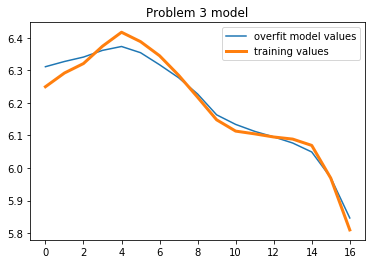

Overfit MAE:  0.021583905777588515


In [31]:
lasso_regressor_overfit = linear_model.Lasso(alpha=0.001, fit_intercept=False, tol=0.01, max_iter=10000)

#this fits the outputs Y to the polynomial basis of inputs in the range -2 to 2
lasso_regressor_overfit.fit(X_train_overfit, Y_train_raw_prob_3)

#these are the weights the model learns
w_overfit = lasso_regressor_overfit.coef_

plt.title("Problem 3 model")
plt.plot(X_train_overfit.dot(w_overfit), label="overfit model values")
plt.plot(Y_train_raw_prob_3, lw=3, label="training values")   #our training data
plt.legend()
plt.show()

mae_overfit = np.mean(np.abs(X_train_overfit.dot(w_overfit) - Y_train_raw_prob_3))
print("Overfit MAE: ", mae_overfit)

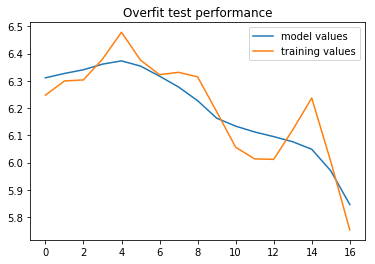

MAE:  0.06249199880728963


In [34]:
plt.title("Overfit test performance")
plt.plot(X_test_overfit.dot(w_overfit), label="model values")   #our model
plt.plot(Y_test_raw_prob_3, label="training values")   #our training data
plt.legend()
plt.show()

print("MAE: ", np.mean(np.abs(X_test_overfit.dot(w_overfit) - Y_test_raw_prob_3)))